1. Importing the necessary Python libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold, PredefinedSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

2. Data Loading and Preprocessing

In [4]:
df  = pd.read_csv('../data/Telco_Customer_Churn_Dataset.csv')
df.head()


# Checking Missing Values
df.isna().sum().sum()
# Information of features
df.info()
# Summary of numeric features
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Visualization of Dataset

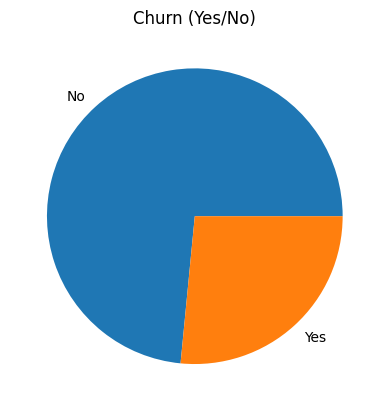

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df['Churn'].value_counts().plot(kind="pie")
plt.title("Churn (Yes/No)")

plt.show()

df['Churn'].value_counts()

In [6]:
results = {}

results["Churn vs MonthlyCharges"] = df.groupby("Churn")["MonthlyCharges"].mean()
results["Gender vs MonthlyCharges"] = df.groupby("gender")["MonthlyCharges"].mean()
results["Churn+Gender vs MonthlyCharges"] = df.groupby(["Churn", "gender"])["MonthlyCharges"].mean()
results["Churn vs Tenure"] = df.groupby("Churn")["tenure"].mean()
results["Contract vs MonthlyCharges"] = df.groupby("Contract")["MonthlyCharges"].mean()
results["Churn vs Contract"] = df.groupby("Churn")["Contract"].value_counts()
results["Churn vs Partner"] = df.groupby("Churn")["Partner"].value_counts()
results["Churn vs InternetService"] = df.groupby("Churn")["InternetService"].value_counts()

for name, result in results.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(result)


Churn vs MonthlyCharges
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Gender vs MonthlyCharges
gender
Female    65.204243
Male      64.327482
Name: MonthlyCharges, dtype: float64

Churn+Gender vs MonthlyCharges
Churn  gender
No     Female    61.664908
       Male      60.876914
Yes    Female    74.812087
       Male      74.066989
Name: MonthlyCharges, dtype: float64

Churn vs Tenure
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

Contract vs MonthlyCharges
Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64

Churn vs Contract
Churn  Contract      
No     Month-to-month    2220
       Two year          1647
       One year          1307
Yes    Month-to-month    1655
       One year           166
       Two year            48
Name: count, dtype: int64

Churn vs Partner
Churn  Partner
No     Yes        2733
       No         2441
Yes    No         1200
    

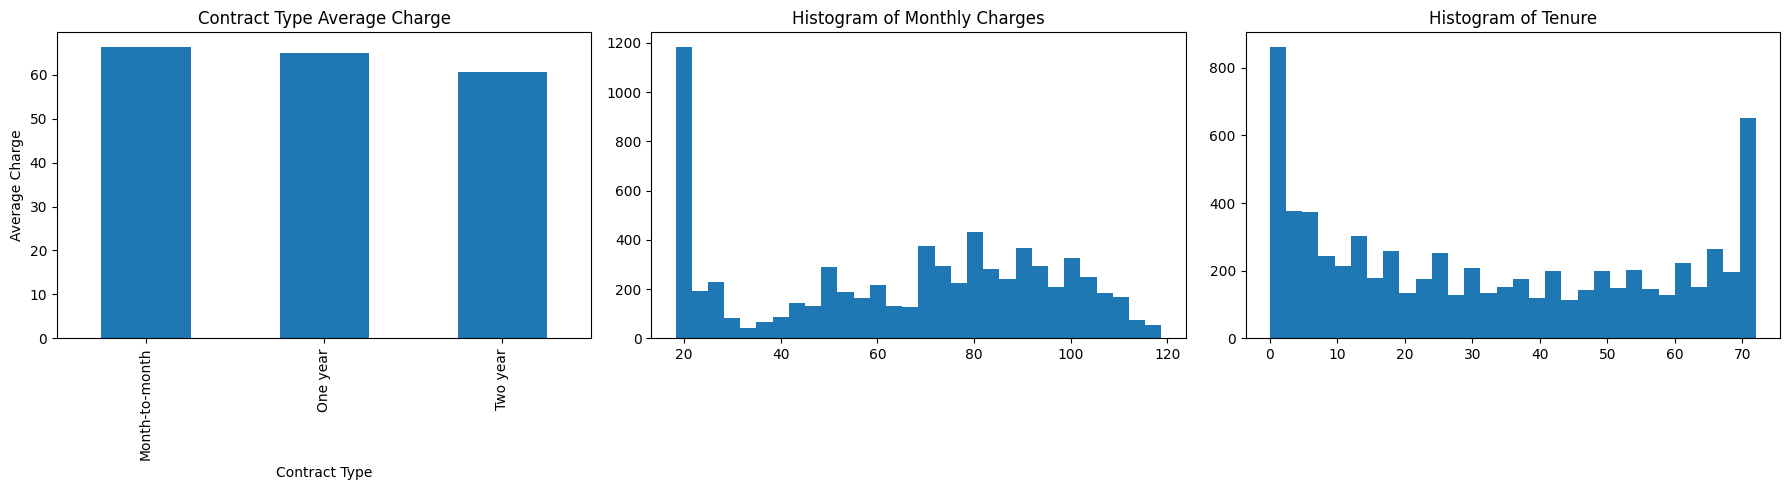

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Contract vs Monthly Charges (bar plot)
df.groupby("Contract")["MonthlyCharges"].mean().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Contract Type Average Charge")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Average Charge")

# 2. Histogram of Monthly Charges
axes[1].hist(df["MonthlyCharges"], bins=30)
axes[1].set_title("Histogram of Monthly Charges")

# 3. Histogram of Tenure
axes[2].hist(df["tenure"], bins=30)
axes[2].set_title("Histogram of Tenure")

plt.tight_layout()
plt.show()

Note: This result indicates that when the monthly average charge is increases, more customers stop using the service

In [8]:
# ======================
# LABEL
# ======================
label_data = df["Churn"].map({"Yes": 1, "No": 0})

# ======================
# FEATURES
# ======================
feature_data = df.drop(["Churn", "customerID"], axis=1)

# ======================
# Fix numeric column
# ======================
feature_data["TotalCharges"] = pd.to_numeric(
    feature_data["TotalCharges"],
    errors="coerce"
)

# Fill missing values
feature_data.fillna(
    feature_data.median(numeric_only=True),
    inplace=True
)

# ======================
# Identify categorical columns
# ======================
# Identify categorical columns (future-proof)
categorical_cols = feature_data.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

binary_cols = []
multi_cols = []

for col in categorical_cols:
    unique_vals = set(feature_data[col].dropna().unique())

    # TRUE binary columns ONLY
    if unique_vals == {"Yes", "No"}:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

# ======================
# Encode Binary Columns
# ======================
feature_data[binary_cols] = feature_data[binary_cols].replace(
    {"Yes": 1, "No": 0}
)

# ======================
# One-Hot Encoding
# ======================
feature_data = pd.get_dummies(
    feature_data,
    columns=multi_cols,
    drop_first=True
)

# ======================
# FINAL CHECK
# ======================
print(feature_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   object 
 2   Dependents                             7043 non-null   object 
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   object 
 5   PaperlessBilling                       7043 non-null   object 
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   gender_Male                            7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  InternetService

Data Splitting

In [9]:
# Step 1: split into train and temp (test+val)
X_train, X_temp, y_train, y_temp = train_test_split(
    feature_data,
    label_data,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=label_data
)

# Step 2: split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True,
    stratify=y_temp
)

print(X_train.shape)

(5634, 30)


Feature Selection

In [10]:
correlation = feature_data.corrwith(label_data).sort_values(ascending=False)

print(correlation)

InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226
Contract_One year                       -0.177820


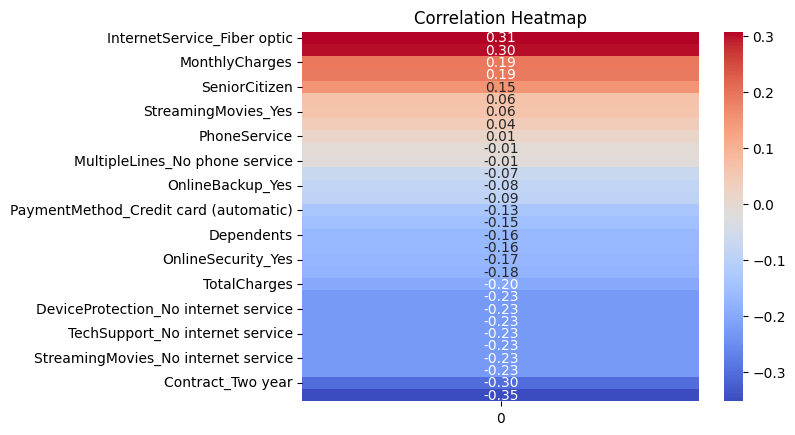

In [11]:
sns.heatmap(correlation.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# Step 1: Univariate selection (chi2)
# Note: X must be non-negative for chi2
X_chi = feature_data.copy()
X_chi[X_chi < 0] = 0  # shift any negative values to zero

selector = SelectKBest(score_func=chi2, k=30)  # keep top 30
X_selected_chi = selector.fit_transform(X_chi, label_data)
selected_cols_chi = feature_data.columns[selector.get_support()]

# Step 2: Random Forest importance on top features
rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(feature_data[selected_cols_chi], label_data)

importances = pd.Series(rf.feature_importances_, index=selected_cols_chi)
importances = importances.sort_values(ascending=False)

# Step 3: Select final top 15 features
top_features = importances.head(15).index
X_final = feature_data[top_features]

print("Top 15 Features for Churn Prediction:")
print(top_features)

Top 15 Features for Churn Prediction:
Index(['TotalCharges', 'MonthlyCharges', 'tenure',
       'InternetService_Fiber optic', 'PaymentMethod_Electronic check',
       'Contract_Two year', 'gender_Male', 'OnlineSecurity_Yes',
       'PaperlessBilling', 'TechSupport_Yes', 'Partner', 'Contract_One year',
       'OnlineBackup_Yes', 'SeniorCitizen', 'MultipleLines_Yes'],
      dtype='str')


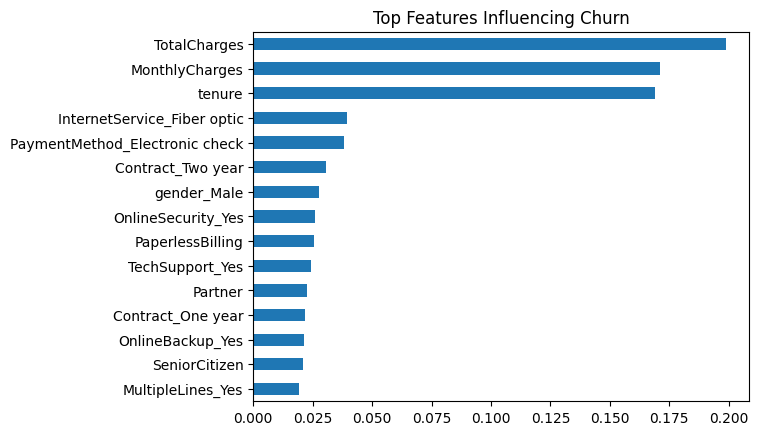

In [13]:
importances.head(15).plot(kind="barh")
plt.title("Top Features Influencing Churn")
plt.gca().invert_yaxis()
plt.show()

In [17]:
# Final Dataset with selected features
X_train_top = X_train[top_features]
y_train_top = y_train
X_val_top = X_val[top_features]
y_val_top = y_val
X_test_top = X_test[top_features]
y_test_top = y_test

In [ ]:
# Combine train and validation data
X_combined = np.vstack((X_train_top, X_val_top))
y_combined = np.hstack((y_train_top, y_val_top))

# Create a test_fold array: -1 for training, 0 for validation
test_fold = np.array([-1]*len(X_train_top) + [0]*len(X_val_top))
ps = PredefinedSplit(test_fold)

Model Selection

In [14]:
# Selcting The Best ML Model
param_grid = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ["liblinear", "lbfgs"]
        }
    },
    "SVM": {
        "model": SVC(random_state=42, probability=True),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20]
        }
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "learning_rate": [0.01, 0.1, 1]
        }
    }
}

In [ ]:
# Selecting best model using GridSearchCV with predefined validation split
best_models = {}
validation_scores = {}

for name, mp in param_grid.items():
    print(f"Running GridSearchCV for {name} using predefined validation split...")
    
    model = mp["model"]
    
    # Use GridSearchCV with PredefinedSplit
    grid = GridSearchCV(
        estimator=model,
        param_grid=mp["params"],
        cv=ps,                  # use our predefined train/val split
        scoring="accuracy",
        n_jobs=-1
    )
    
    grid.fit(X_combined, y_combined)
    
    best_models[name] = grid.best_estimator_
    
    # Get validation score for the best hyperparameters
    validation_score = grid.cv_results_['mean_test_score'][grid.best_index_]
    validation_scores[name] = validation_score
    
    print(f"Best params for {name}: {grid.best_params_}")
    print(f"Validation accuracy: {validation_score:.4f}")

# Find the best model based on validation accuracy
best_model_name = max(validation_scores, key=validation_scores.get)
print(f"\nBest model overall: {best_model_name} with validation accuracy {validation_scores[best_model_name]:.4f}")

Running GridSearchCV for Logistic Regression using predefined validation split...


/Users/mulatyazewchekol/Documents/My_Projects/Machine_Learning_Internship_At_Saiket_Systems/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best params for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}
Validation accuracy: 0.8082
Running GridSearchCV for SVM using predefined validation split...
Best params for SVM: {'C': 1, 'kernel': 'linear'}
Validation accuracy: 0.8026
Running GridSearchCV for Random Forest using predefined validation split...
Best params for Random Forest: {'max_depth': 10, 'n_estimators': 200}
Validation accuracy: 0.8210
Running GridSearchCV for AdaBoost using predefined validation split...
Best params for AdaBoost: {'learning_rate': 1, 'n_estimators': 50}
Validation accuracy: 0.7983

Best model overall: Random Forest with validation accuracy 0.8210


### Final Model Selection Summary

* **Best accuracy model:** Random Forest

  * Validation accuracy = **0.8210**
  * Higher **time complexity** (many trees)
  * Higher **memory usage** (stores 200 decision trees)

* **Best efficiency model:** Logistic Regression

  * Validation accuracy = **0.8082**
  * Very **low time complexity**
  * Very **low memory complexity**
  * Fast training and prediction

### 📊 Accuracy Trade-off

Accuracy loss when choosing Logistic Regression instead of Random Forest:

[
0.8210 - 0.8082 = 0.0128 \approx 1.28%
]

👉 You lose only **~1.3% accuracy**.



### ⭐ Final Decision

**Logistic Regression is the best final model** when considering **time complexity + memory efficiency**, because it achieves nearly the same performance while being much lighter and faster than Random Forest.

**Final choice:** **Logistic Regression**
**Accuracy sacrificed:** ≈ **1.3%** only.


5. Model Training

In [52]:
best_model = LogisticRegression(
    C=0.1,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# Train model
best_model.fit(X_combined, y_combined)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Model Evaluation

In [53]:
# Predictions
y_pred = best_model.predict(X_test_top.values)
y_prob = best_model.predict_proba(X_test_top.values)[:, 1]

In [54]:
print(confusion_matrix(y_test_top, y_pred))

[[465  53]
 [ 97  90]]


In [55]:
accuracy = accuracy_score(y_test_top, y_pred)
precision = precision_score(y_test_top, y_pred)
recall = recall_score(y_test_top, y_pred)
f1 = f1_score(y_test_top, y_pred)
roc_auc = roc_auc_score(y_test_top, y_prob)

# Create table
metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

print(metrics_table)

      Metric     Score
0   Accuracy  0.787234
1  Precision  0.629371
2     Recall  0.481283
3   F1-score  0.545455
4    ROC-AUC  0.824071
